# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [ ]:
STUDENT_NAME = "Nguyễn Trọng Phúc"  # TODO: Họ và tên
STUDENT_ID = "2510194"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\TU HOC\AI\HCMUT\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [2]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [7]:
# TODO N1
# shifted_logits = ...
row_max = np.max(logits, axis = 1, keepdims = True)

shifted_logits = logits - row_max
# exp_logits = ...
exp_logits = np.exp(shifted_logits)

# class_probabilities = ...
class_probabilities = exp_logits / np.sum(exp_logits, axis = 1, keepdims = True)

# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis = 1)

# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis = 1)

In [ ]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [9]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [10]:
# TODO N2
# train_feature_mean = ...
train_feature_mean = np.mean(X_train, axis = 0)

# train_feature_std = ...
train_feature_std = np.std(X_train, axis = 0)

# X_train_scaled = ...
X_train_scaled = (X_train - train_feature_mean) / train_feature_std

# X_val_scaled = ...
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [12]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [13]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [14]:
# TODO N3
# correct_mask = ...
correct_mask = (predicted_classes == true_labels)

# high_confidence_mask = ...
high_confidence_mask = (confidence_scores >= confidence_threshold)

# review_mask = ...
review_mask = (~correct_mask) | (~high_confidence_mask)

# review_indices = ...
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [16]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [17]:
# TODO N4
# normalized_batch = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

# augmented_batch = ... 
augmented_batch = normalized_batch[:, :, ::-1, :].copy()

# augmented_batch[0, 0, 0, 0] = ...
augmented_batch[0,0,0,0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. --> 
1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports

2. Ký hiệu missing value trong file CSV được viết dưới dạng dấu ?

3. Symboling thể hiện mức đánh giá rủi ro bảo hiểm (từ -3 đến 3)

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [18]:
# TODO D1
# raw_df = ...
raw_df = pd.read_csv(DATA_PATH)

# raw_shape = ...
raw_shape = raw_df.shape

# raw_missing_marker_count = ...
raw_missing_marker_count = (raw_df == "?").sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [20]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [21]:
# TODO D2
# df_clean = ...
df_clean = raw_df.replace("?", np.nan).copy()

# for column in NUMERIC_COLUMNS:
#     ...
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors = "coerce")

# missing_by_column = ...
missing_by_column = df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
1. Vì có những cột khác thứ nguyên với nhau, ví dụ như engine_size đo bằng đơn vị thể tích, trong khi price đo bằng USD. Theo đó, nếu điền chung 1 giá trị sẽ làm giảm độ chính xác, vì khi huấn luyện, máy sẽ học từ sự tương quan giữa các cột, việc dùng chung 1 giá trị sẽ làm cho mô hình không tìm thấy mối liên hệ nào giữa các đặc điểm. Bên cạnh đó nó cũng làm ảnh hưởng tới mean và độ lệch chuẩn. 

2. Với price, lựa chọn drop sẽ phù hợp hơn vì price là mục tiêu chính mà ta muốn phân tích, nếu điền giá trị giả vào các missing value tại price, ta sẽ tạo ra các điểm dữ liệu gây nhiễu và khả năng cao sẽ làm sai lệch nghiêm trọng.

3. Trong trường hợp normalized_losses thiếu nhiều dữ liệu hơn các cột khác, cụ thể là 41 trên 205 dữ liệu bị thiếu, tức là 20%, nếu xóa các dòng chứa NaN ở cột này, ta sẽ bỏ đi 20% lượng dữ liệu của toàn bộ các cột khác, điều này có thể gây ảnh hưởng tới việc học của mô hình. Do đó, nếu cột này không quá quan trọng, ta có thể bỏ qua nó khi phân tích. Ngược lại, nếu cột này cần thiết để khảo sát thì sẽ dùng các kỹ thuật khác nhau để điền vào các vị trí missing value.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [22]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [23]:
# TODO D3
# analysis_df = ...
analysis_df = df_clean[AUTO_FEATURES].dropna()

# X_auto = ...
X_auto = analysis_df.to_numpy(dtype = np.float64)

# auto_feature_mean = ...
auto_feature_mean = np.mean(X_auto, axis = 0)

# auto_feature_std = ...
auto_feature_std = np.std(X_auto, axis = 0)

# X_auto_scaled = ...
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [24]:
# TODO D4
# price_index = ...
price_index = AUTO_FEATURES.index("price")

# price_z = ...
price_z = X_auto_scaled[:, price_index]

# price_outlier_mask = ...
price_outlier_mask = np.abs(price_z) > 2

# price_outliers = ...
price_outliers = X_auto[price_outlier_mask, price_index]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [25]:
# TODO D5
# engine_price_corr = ...
engine_index = AUTO_FEATURES.index("engine_size")

engine_price_corr = np.corrcoef(X_auto[:, engine_index], X_auto[:, price_index])[0,1]

# price_by_body_style = ...
price_by_body_style = df_clean.groupby("body_style")["price"].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

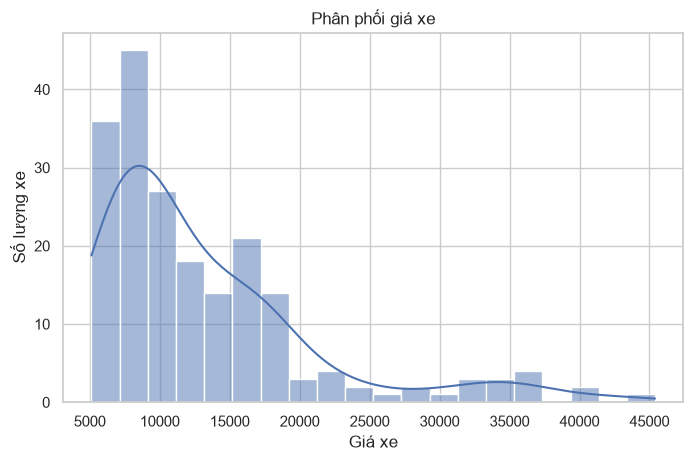

In [ ]:
# TODO M2.1: histogram/KDE của price
sns.histplot(data = df_clean, x = "price", kde = True, bins = 20)

plt.title("Phân phối giá xe")
plt.xlabel("Giá xe")
plt.ylabel("Số lượng xe")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Biểu đồ cho thấy phân phối giá xe bị lệch phải mạnh, đa số các mẫu xe tập trung ở phân khúc dưới $15000 và số ít các xe hạng sang có mức giá hơn $20000

## M2.2 Dataset có cân bằng theo body style không?

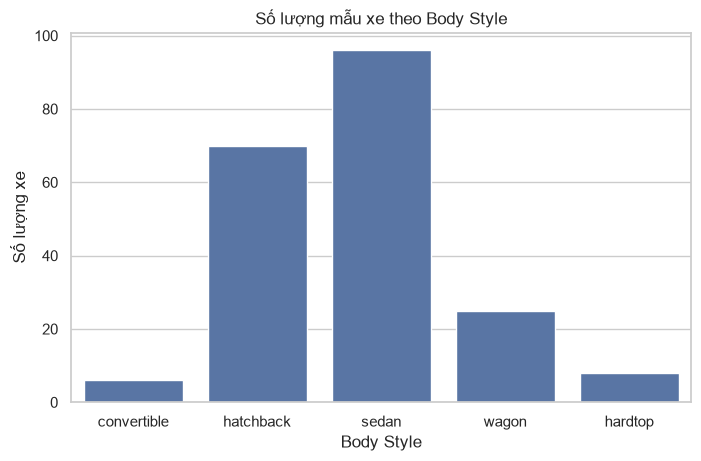

In [ ]:
# TODO M2.2: countplot của body_style
sns.countplot(data = df_clean, x = "body_style")

plt.title("Phân bố số lượng mẫu xe theo body_style")
plt.xlabel("Body Style")
plt.ylabel("Số lượng xe")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Biểu đồ cho thấy sự chênh lệch rõ rệt, 2 dòng xe sedan và hatchback chiếm số lượng rất lớn trong khi các dòng còn lại có ít mẫu hơn rất nhiều

## M2.3 Price khác nhau theo body style ra sao?

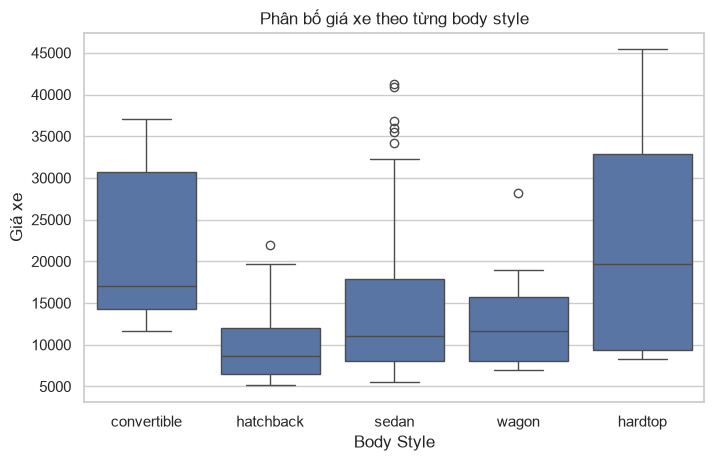

In [ ]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data = df_clean, x = "body_style", y = "price")

plt.title("Phân bố giá xe theo từng body_style")
plt.xlabel("Body Style")
plt.ylabel("Price")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Có thể thấy, hatchback là dòng xe có giá thành dễ tiếp cận và phổ biến nhất. Trong khi convertible và hadtop lại hướng tới phân khúc cao cấp với mức giá median cao nhất, riêng dòng sedan chứa nhiều giá trị outliers ở phân khúc giá cao

## M2.4 Engine size liên quan thế nào tới price?

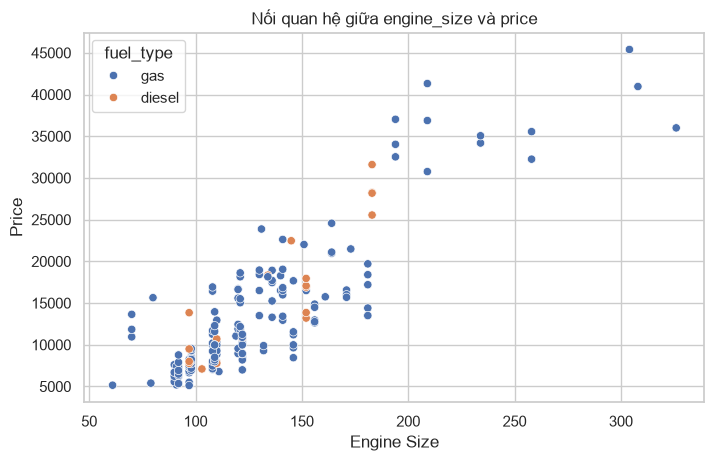

In [32]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(data = df_clean, x = "engine_size", y = "price", hue = "fuel_type")

plt.title("Nối quan hệ giữa engine_size và price")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()


**Nhận xét:** <!-- 1--2 câu -->
Hai đại lượng này có mối tương quan thuận khá rõ nét, dung tích động cơ lớn thì giá xe cao. Bên cạnh đó thì nhóm xe chạy bằng dầu diesel dù không chiếm đa số nhưng có xu hướng giữ giá ổn so với xe chạy xăng ở cùng mức dung tích

## M2.5 Các feature numeric tương quan ra sao?

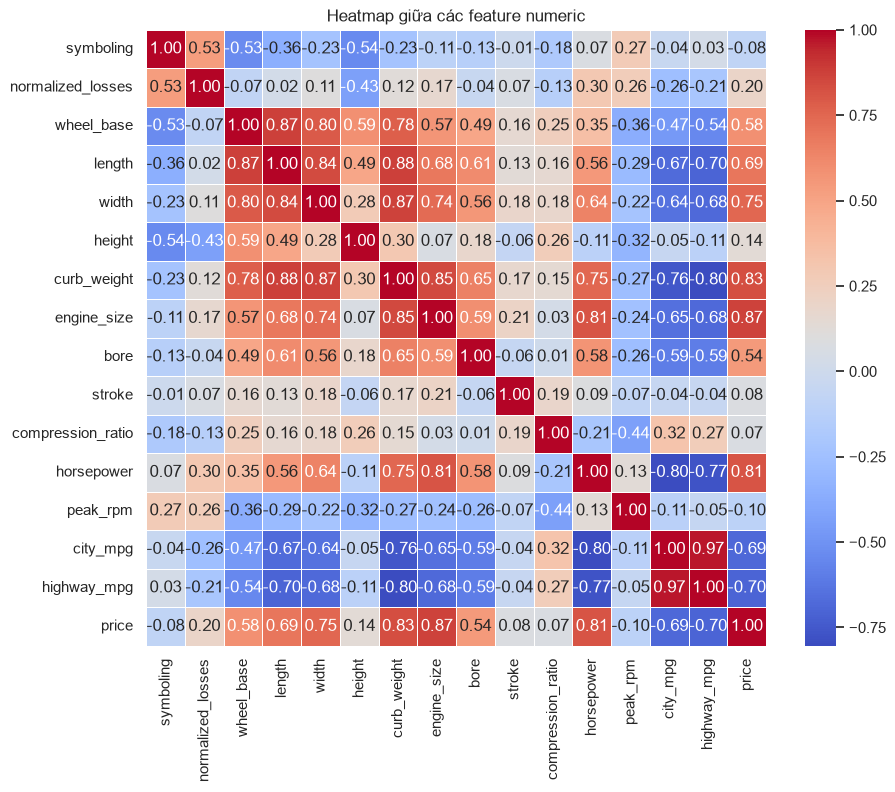

In [33]:
# TODO M2.5: correlation heatmap
numeric_cols = df_clean.select_dtypes(include=["float64", "int64"])

plt.figure(figsize = (10,8))

sns.heatmap(numeric_cols.corr(), annot = True, cmap = "coolwarm", fmt = ".2f", linewidths = 0.5)

plt.title("Heatmap giữa các feature numeric")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Heatmap cho thấy price có tương quan thuận rất mạnh với engine_size và curb_weight, nhưng lại tương quan nghịch mạnh với mức tiết kiệm nhiên liệu như city_mpg và highway_mpg

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

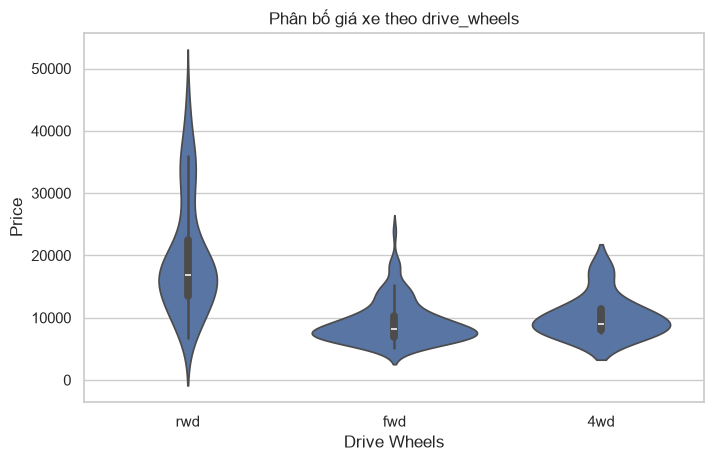

In [35]:
# TODO M2.6: biểu đồ tự chọn
sns.violinplot(data = df_clean, x = "drive_wheels", y = "price")

plt.title("Phân bố giá xe theo drive_wheels")
plt.xlabel("Drive Wheels")
plt.ylabel("Price")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Câu hỏi: Nêu ra mối quan hệ giữa price và drive_wheels

Biểu đồ violin cho thấy xe cầu sau (rwd) có mức giá phân tán rất rộng, trong khi đó xe cầu trước có phần bụng phình to ở phân khúc dưới $10000, chứng tỏ đại đa số xe fwd tập trung rất nhiều ở mức giá này.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->
1. Các phát hiện chính:
- Phân phối giá xe bị lệch phải, đa số xe thuộc phân khúc dưới $15000, rất ít xe vượt mốc $30000
- Ở countplot M2.2, biểu đồ cho thấy sự mất cân bằng theo biến body_style, sedan và hatchback chiếm áp đảo thị phần, trong khi convertible hay hardtop rất hiếm gặp
- Trong heatmap ở M2.5, tương quan engine_size - price thuận rất mạnh, tương quan nghịch engine_size - city_mpg và highway_mpg rất mạnh
- Trong M2.6, violinplot cho thấy xe cầu sau rwd có mức giá phân tán rất rộng, trong khi xe cầu trước fwd lại có số lượng tập trung vào phân khúc dưới $10000

2. Hạn chế của dataset:
- Missing value: Biến normalized_losses thiếu tới 20% dữ liệu (41 trên 205), có khả năng gây ảnh hưởng tới quá trình học của mô hình nếu giữ lại
- Số dữ liệu không quá lớn và phân bố lệch khá nặng về 1 số nhóm hay phân khúc.

3. Ví dụ về corr không đồng nghĩa với causation:
- price và city_mpg có tương quan nghịch rất mạnh nhưng giá bán đắt không trực tiếp làm xe tốn nhiều xăng hơn. Nguyên nhân là vì khi price cao thì engine_size cũng có xu hướng tăng (vì giá cao thì thường dung tích động cơ sẽ lớn hơn), chính điều này làm cho city_pmg tăng chứ không trực tiếp do price.

4. Câu hỏi nên phân tích tiếp: Liệu có cách nào xác định xem biến normalized_losses có thật sự cần thiết hay không để có thể điền khuyết thay vì bỏ cả cột này? Trong trường hợp ta thấy nó cần thiết thì ta sẽ điền khuyết như thế nào? Có cần phải xem xét các thông số ở các cột khác để thiết kế ra được một thuật toán hay một chiến thuật để "khôi phục" 20% dữ liệu bị khuyết của biến này hay không?


